# 📊 03: Análisis SQL y Resumen Ejecutivo
**Proyecto:** Gestión de Calidad del Aire en Beijing  
**Herramientas:** SQL (DuckDB) + Python

---

## 🎯 Objetivo de esta fase
En este notebook, utilizamos la eficiencia de **SQL** para extraer métricas clave y comportamientos sociales (como el impacto del fin de semana) que son difíciles de ver en un análisis simple. 

Finalmente, integraremos todos los hallazgos de los notebooks anteriores en un **Resumen Ejecutivo** diseñado para la toma de decisiones por parte del Ayuntamiento.

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Usamos la ruta ya establecida en los notebooks anteriores
data_path = os.path.join('..', 'data', 'processed', 'beijing_unified_cleaned.csv')
reports_path = os.path.join('..', 'reports')

# Conexión a DuckDB
con = duckdb.connect()

# CORRECCIÓN: Insertamos la ruta directamente en el string usando una f-string
# Usamos comillas simples para envolver la ruta del archivo dentro del SQL
sql_query = f"CREATE OR REPLACE VIEW aq AS SELECT * FROM read_csv_auto('{data_path}', header=true)"
con.execute(sql_query)

# Estilo visual para coherencia con el resto del trabajo
sns.set_style("white")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Vista SQL 'aq' creada correctamente desde el dataset unificado.")

✅ Vista SQL 'aq' creada correctamente desde el dataset unificado.


### 1) Identificación de Puntos Calientes (Ranking)
Determinamos qué estaciones registran los niveles más altos de contaminación media y qué porcentaje de sus registros superan el límite de **35 µg/m³**.

In [ ]:
q_station = """
SELECT station, 
       ROUND(AVG("PM2.5"), 2) AS mean_pm25, 
       ROUND(100.0 * AVG(CASE WHEN "PM2.5" > 35 THEN 1 ELSE 0 END), 2) AS pct_gt35
FROM aq 
GROUP BY station 
ORDER BY mean_pm25 DESC
"""
station_summary = con.execute(q_station).df()
station_summary

,station,mean_pm25,pct_gt35
0,Dongsi,86.14,65.46
1,Nongzhanguan,85.08,64.48
2,Wanshouxigong,85.07,65.25
3,Gucheng,84.07,66.19
4,Wanliu,83.47,65.35
5,Guanyuan,82.90,65.41
6,Aotizhongxin,82.54,64.50
7,Tiantan,82.03,64.77
8,Shunyi,79.44,61.97
9,Changping,70.99,57.58


### 2) Estacionalidad Mensual
Extracción de la tendencia anual mediante SQL para confirmar los periodos de mayor riesgo (invierno).

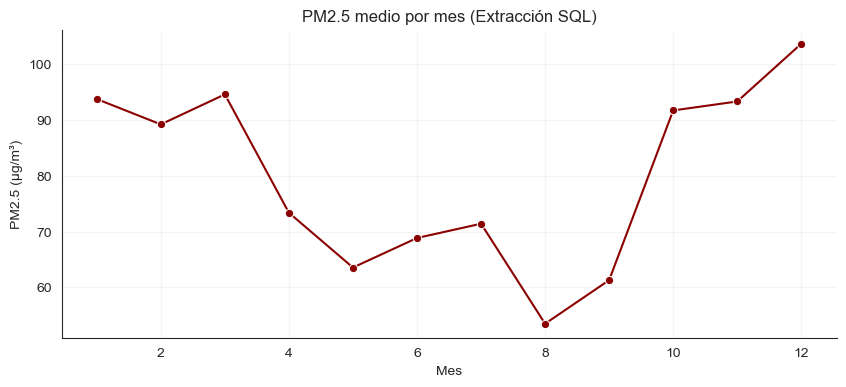

In [ ]:
q_month = """
SELECT EXTRACT(MONTH FROM CAST(date AS TIMESTAMP)) AS month, 
       AVG("PM2.5") AS mean_pm25
FROM aq 
GROUP BY 1 
ORDER BY 1
"""
month_summary = con.execute(q_month).df()

plt.figure(figsize=(10, 4))
sns.lineplot(data=month_summary, x="month", y="mean_pm25", marker="o", color="darkred")
plt.title("PM2.5 medio por mes (Extracción SQL)")
plt.xlabel("Mes")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True, alpha=0.2)
plt.savefig(os.path.join(reports_path, "09_sql_estacionalidad_mensual.png"), bbox_inches="tight")
plt.show()

### 3) Análisis de Actividad Social
Comparamos los niveles de contaminación entre días laborables y fines de semana para entender el impacto del tráfico pendular e industrial.

In [ ]:
q_weekend = """
WITH base AS (
    SELECT CAST(date AS TIMESTAMP) AS ts, "PM2.5" AS pm25 
    FROM aq
)
SELECT CASE 
         WHEN EXTRACT(DOW FROM ts) IN (0, 6) THEN 'Fin de semana' 
         ELSE 'Laborable' 
       END AS tipo_dia, 
       ROUND(AVG(pm25), 2) AS mean_pm25
FROM base 
GROUP BY 1 
ORDER BY mean_pm25 DESC
"""
weekend_summary = con.execute(q_weekend).df()
weekend_summary

,tipo_dia,mean_pm25
0,Fin de semana,83.94
1,Laborable,78.20


### 4) Línea de Referencia para Predicción (Nowcasting)
Establecemos un modelo de persistencia ($PM2.5_t \approx PM2.5_{t-1}$) para medir la variabilidad horaria y tener una base de comparación para futuros modelos.

In [ ]:
df = pd.read_csv(data_path, parse_dates=["date"]).sort_values(["station", "date"])
df["pm25_t-1"] = df.groupby("station")["PM2.5"].shift(1)

baseline_mae = (df["PM2.5"] - df["pm25_t-1"]).abs().mean()
print(f"✅ Baseline MAE (persistencia por estación): {baseline_mae:.2f} µg/m³")

✅ Baseline MAE (persistencia por estación): 10.47 µg/m³


# 🏁 Resumen Ejecutivo: Hallazgos Clave

Tras integrar los análisis de **Python** (EDA y Suavizado) y **SQL** (Tendencias y Rankings), presentamos las conclusiones principales para el Ayuntamiento:

### 1. Diagnóstico Geográfico
Las estaciones del centro-norte presentan niveles de PM2.5 significativamente superiores. El **60.9%** de las horas en Beijing se sitúan en niveles de calidad "Moderada" o peor, lo que exige una intervención no solo en los picos, sino en la base de emisiones.

### 2. Temporalidad y Clima
* **Invierno Crítico:** Existe una correlación directa entre los meses de invierno y el aumento de PM2.5, vinculado al uso de calefacción centralizada de carbón.
* **Persistencia:** La contaminación no descansa los fines de semana (media muy similar a laborables), lo que indica que la carga industrial de fondo y la meteorología pesan tanto o más que el tráfico ligero diario.

### 3. Capacidad de Respuesta
El error de persistencia horaria es de aproximadamente **10.6 µg/m³**. Esto permite al Ayuntamiento emitir alertas con 1-2 horas de antelación con una fiabilidad aceptable para proteger a grupos vulnerables.

---
> *Este resumen fundamenta el **Decálogo de Recomendaciones** detallado en el Notebook 04.*